Plot the NN Performance
=======================

Currently presenting NNv0.1.1 results

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib.colors as colors

import seaborn as sns

In [2]:
infile = '/Users/yuntse/data/lartpc_rd/gampix/nn/radiologicals/gampixpy_fullgeoanatruth-vd-reduced_g4_00_2Mhz_segmentlabel_lowtrig_5mmpitch_good_r3sd_nn0.1.1.csv'

In [3]:
df = pd.read_csv(infile, header = 0)
df

,tile_id,event id,start t,tile x,tile y,charge,fit_amp,fit_mu,fit_sigma,fit_rmse,...,ratio,ratio_3sd,ratio_fit,ratio_fit_3sd,E,z_avg,drift_avg,dQdn,pred_drift,isTraining
0,0,0,5806.4365,-1065.0,-575.0,965.778880,173.146760,1.800038,0.939798,50.072464,...,0.817486,0.159968,1.081924,0.000000,0.103476,-308.29733,633.297360,482.889440,347.849344,True
1,2,0,-3550.5635,-1055.0,-575.0,234.433332,43.891174,0.731231,1.514144,58.922040,...,2.075628,0.952930,0.983764,0.000000,0.034409,323.14770,1.852295,234.433332,61.715560,True
2,7,0,3298.9365,-1055.0,-475.0,12518.798948,10943.854000,2.043829,0.223080,53.229670,...,0.959932,0.985262,0.978196,0.978195,0.617345,318.25034,6.749664,6259.399474,4.511363,True
3,9,0,3335.9365,-1045.0,-565.0,3507.947205,576.551800,3.167966,1.183960,59.723280,...,1.198787,0.490605,1.215465,0.178767,0.271025,-162.54642,487.546420,584.657867,425.554403,True
4,11,0,1990.4365,-1045.0,-545.0,3061.282373,558.148500,3.204277,1.081603,35.422250,...,0.957875,0.104500,0.837892,0.000000,0.242734,-171.63080,496.630800,765.320593,423.045144,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
723544,888941,999,-3249.3162,-735.0,-485.0,1978.233573,1409.283100,1.505412,0.248886,134.820300,...,0.904431,0.920586,0.789981,0.789865,0.134956,323.69696,1.303040,1978.233573,7.286161,True
723545,888943,999,-3057.3162,-735.0,-485.0,4061.857259,2146.497600,1.945175,0.366560,46.033340,...,1.034290,0.972351,1.018388,1.018214,0.243623,292.87340,32.126587,2030.928630,31.557749,True
723546,888944,999,2226.1838,-735.0,-365.0,1370.368824,532.412540,1.576690,0.344328,70.419945,...,0.629773,0.505224,0.824121,0.812401,0.086229,318.06238,6.937622,1370.368824,20.006914,False
723547,888945,999,2381.1838,-735.0,-355.0,34824.065399,4619.398400,5.120800,1.504715,91.878580,...,0.990922,0.849475,1.002991,0.857276,1.790287,-314.51718,639.517200,2487.433243,635.855019,True


In [4]:
def plot_drift_performance(
    df,
    ref_col = "drift_avg",
    compare_col = "pred_drift",
    bin_width = 25,
    min_entries = 1,
    min_val = 0,
    max_val = 650
):
    """
    Make violin, bias, resolution, relative bias, and relative resolution plots.

    Parameters
    ----------
    df : pandas.DataFrame
        Input dataframe containing truth and prediction columns.
    truth_col : str
        Column name for true/reference value.
    pred_col : str
        Column name for predicted value.
    bin_width : float
        Width of truth bins, e.g. 20 for 20 cm bins.
    min_entries : int
        Minimum number of entries required in a bin to keep it.
    figsize_violin : tuple
        Figure size for violin plot.
    figsize_summary : tuple
        Figure size for summary plots.

    Returns
    -------
    work_df : pandas.DataFrame
        Copy of input dataframe with derived columns.
    summary : pandas.DataFrame
        Summary table with quantiles and derived metrics.
    """

    work_df = df.copy()

    # keep only finite values
    work_df = work_df[np.isfinite(work_df[ref_col]) & np.isfinite(work_df[compare_col])].copy()

    # derived columns
    work_df["diff"] = work_df[compare_col] - work_df[ref_col]

    # for relative quantities avoid division by zero
    work_df["rel_diff"] = np.nan
    nonzero = work_df[ref_col] != 0
    work_df.loc[nonzero, "rel_diff"] = (
        work_df.loc[nonzero, "diff"] / work_df.loc[nonzero, ref_col]
    )

    # define bins
    # min_val = np.floor(work_df[truth_col].min() / bin_width) * bin_width
    # max_val = np.ceil(work_df[truth_col].max() / bin_width) * bin_width
    bins = np.arange(min_val, max_val + bin_width, bin_width)

    work_df["drift_bin"] = pd.cut(work_df[ref_col], bins = bins, right = False)

    # remove empty / too-small bins
    counts = work_df["drift_bin"].value_counts().sort_index()
    valid_bins = counts[counts >= min_entries].index
    work_df = work_df[work_df["drift_bin"].isin(valid_bins)].copy()

    # ordered labels for plotting
    work_df["drift_bin_label"] = work_df["drift_bin"].apply(
        lambda x: f"[{int(x.left)}, {int(x.right)})"
    )

    # absolute summary
    abs_summary = (
        work_df.groupby("drift_bin", observed = True)["diff"]
        .quantile([0.16, 0.50, 0.84])
        .unstack()
        .rename(columns = {0.16: "diff_q16", 0.50: "diff_q50", 0.84: "diff_q84"})
    )

    # relative summary
    rel_summary = (
        work_df.dropna(subset = ["rel_diff"])
        .groupby("drift_bin", observed = True)["rel_diff"]
        .quantile([0.16, 0.50, 0.84])
        .unstack()
        .rename(columns = {0.16: "rel_q16", 0.50: "rel_q50", 0.84: "rel_q84"})
    )

    # counts and x positions
    count_summary = work_df.groupby("drift_bin", observed = True).size().to_frame("count")

    summary = abs_summary.join(rel_summary, how = "left").join(count_summary, how = "left").reset_index()

    summary["x_center"] = summary["drift_bin"].apply(lambda b: (b.left + b.right) / 2)
    summary["bin_label"] = summary["drift_bin"].apply(lambda b: f"[{int(b.left)}, {int(b.right)})")

    # absolute bias/resolution
    summary["bias"] = summary["diff_q50"]
    summary["bias_err_low"] = summary["diff_q50"] - summary["diff_q16"]
    summary["bias_err_high"] = summary["diff_q84"] - summary["diff_q50"]
    summary["resolution"] = (summary["diff_q84"] - summary["diff_q16"]) / 2.0

    # relative bias/resolution
    summary["rel_bias"] = summary["rel_q50"]
    summary["rel_bias_err_low"] = summary["rel_q50"] - summary["rel_q16"]
    summary["rel_bias_err_high"] = summary["rel_q84"] - summary["rel_q50"]
    summary["rel_resolution"] = (summary["rel_q84"] - summary["rel_q16"]) / 2.0
    
    return work_df, summary

## Performance plots w.r.t. predicted drift distance

In [5]:
work_df_pred, summary_pred = plot_drift_performance(
    df,
    ref_col = "pred_drift",
    compare_col = "drift_avg",
    bin_width = 25
)

In [6]:
figsize_violin = (12, 6)
figsize_summary = (8, 5)

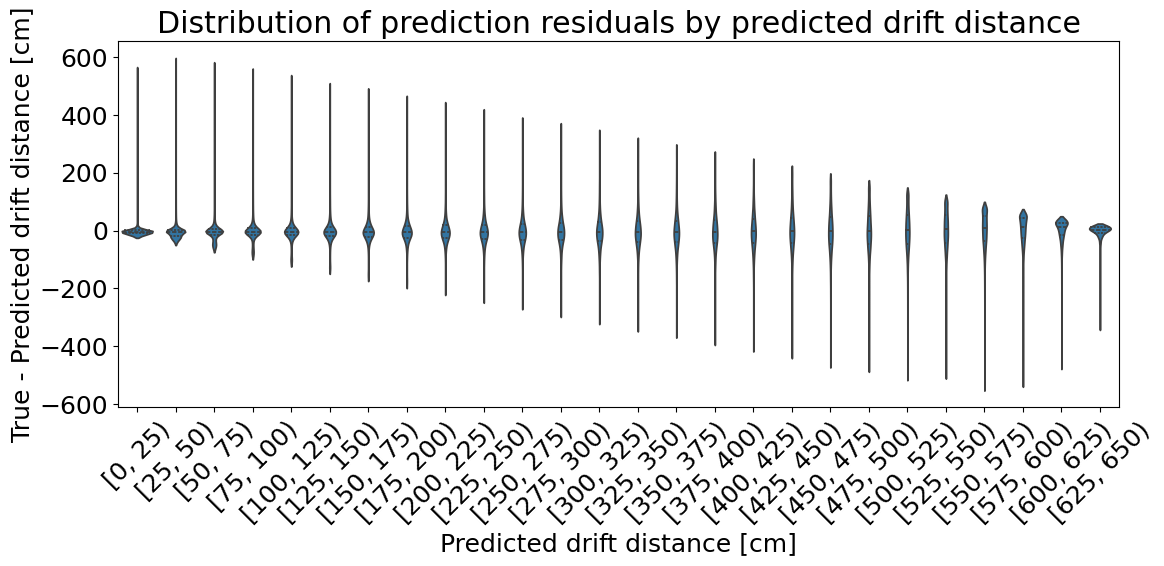

In [7]:
# --------------------
# 1. Violin plot
# --------------------
plt.rcParams.update({"font.size": 18,
                     "axes.labelsize": 18,
                     "xtick.labelsize": 18,
                     "ytick.labelsize": 18,})
fig, ax = plt.subplots(figsize = figsize_violin)

sns.violinplot(
    data = work_df_pred,
    x = "drift_bin_label",
    y = "diff",
    inner = "quartile",
    cut = 0,
    ax = ax
)
ax.set_xlabel(f"Predicted drift distance [cm]")
ax.set_ylabel(f"True - Predicted drift distance [cm]")
ax.set_title("Distribution of prediction residuals by predicted drift distance")
ax.tick_params(axis = "x", labelrotation = 45)
plt.tight_layout()
plt.show()

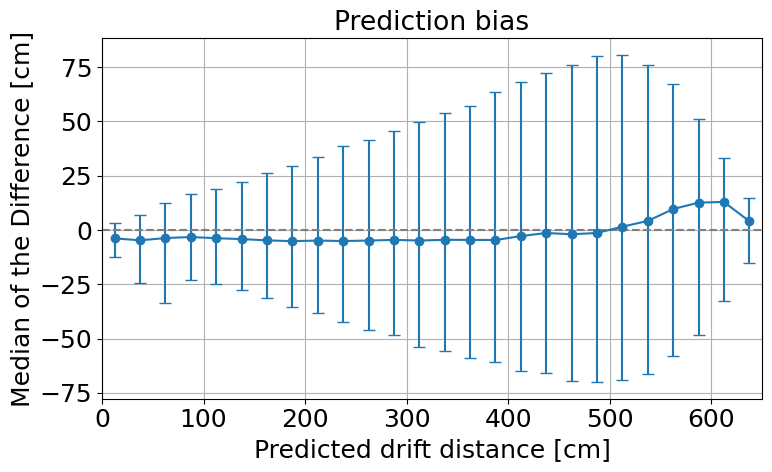

In [8]:
# --------------------
# 2. Bias plot
# --------------------
plt.rcParams.update({"font.size": 16})
fig, ax = plt.subplots(figsize = figsize_summary)

ax.errorbar(
    summary_pred["x_center"],
    summary_pred["bias"],
    yerr = [summary_pred["bias_err_low"], summary_pred["bias_err_high"]],
    fmt = "o-",
    capsize = 4
)

ax.axhline(0, color = "gray", linestyle = "--")
ax.set_xlabel("Predicted drift distance [cm]")
ax.set_ylabel("Median of the Difference [cm]")
ax.set_title("Prediction bias")
ax.set_xlim([0, 650])
ax.grid()
    
plt.tight_layout()
plt.show()

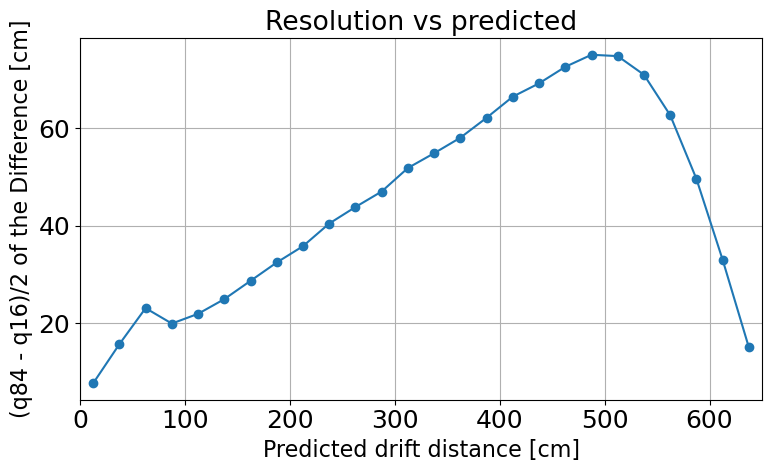

In [9]:
# --------------------
# 3. Resolution plot
# --------------------
plt.rcParams.update({"font.size": 16,
                     "axes.labelsize": 16})
fig, ax = plt.subplots(figsize = figsize_summary)

ax.plot(summary_pred["x_center"], summary_pred["resolution"], "o-")
ax.set_xlabel("Predicted drift distance [cm]")
ax.set_ylabel("(q84 - q16)/2 of the Difference [cm]")
ax.set_title("Resolution vs predicted")
ax.set_xlim([0, 650])
ax.grid()

plt.tight_layout()
plt.show()

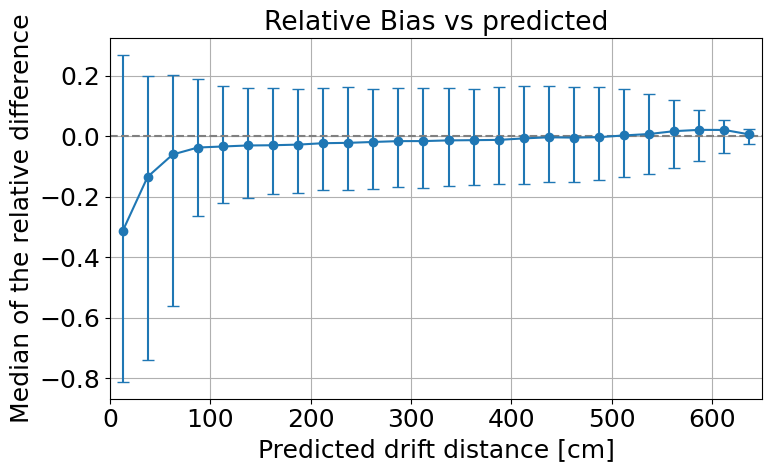

In [10]:
# --------------------
# 4. Relative bias plot
# --------------------
plt.rcParams.update({"font.size": 16,
                     "axes.labelsize": 18})
fig, ax = plt.subplots(figsize = figsize_summary)

ax.errorbar(
    summary_pred["x_center"],
    summary_pred["rel_bias"],
    yerr = [summary_pred["rel_bias_err_low"], summary_pred["rel_bias_err_high"]],
    fmt = "o-",
    capsize = 4
)

ax.axhline(0, color = "gray", linestyle = "--")
ax.set_xlabel("Predicted drift distance [cm]")
ax.set_ylabel(f"Median of the relative difference")
ax.set_title("Relative Bias vs predicted")
ax.set_xlim([0, 650])
ax.grid()
# ax.set_yscale('log')
plt.tight_layout()
plt.show()

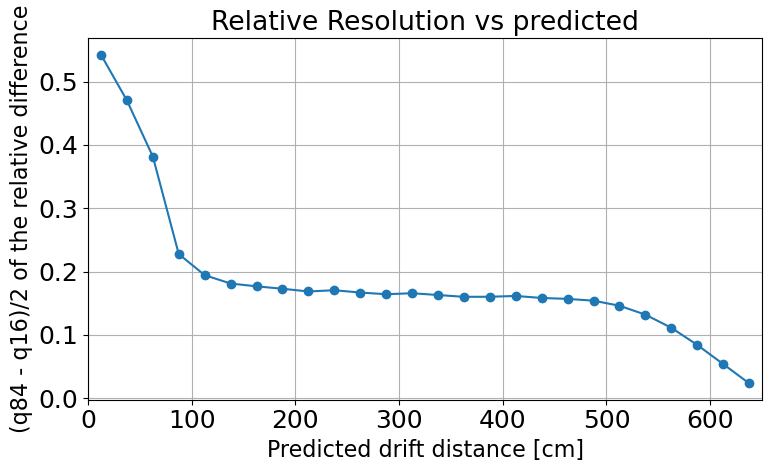

In [11]:
# ---------------------------
# 5. Relative resolution plot
# ---------------------------
plt.rcParams.update({"font.size": 16,
                     "axes.labelsize": 16})
fig, ax = plt.subplots(figsize = figsize_summary)

ax.plot(summary_pred["x_center"], summary_pred["rel_resolution"], "o-")
ax.set_xlabel("Predicted drift distance [cm]")
ax.set_ylabel("(q84 - q16)/2 of the relative difference")
ax.set_title("Relative Resolution vs predicted")
ax.set_xlim([0, 650])
ax.grid()
# ax.set_yscale('log')
plt.tight_layout()
plt.show()

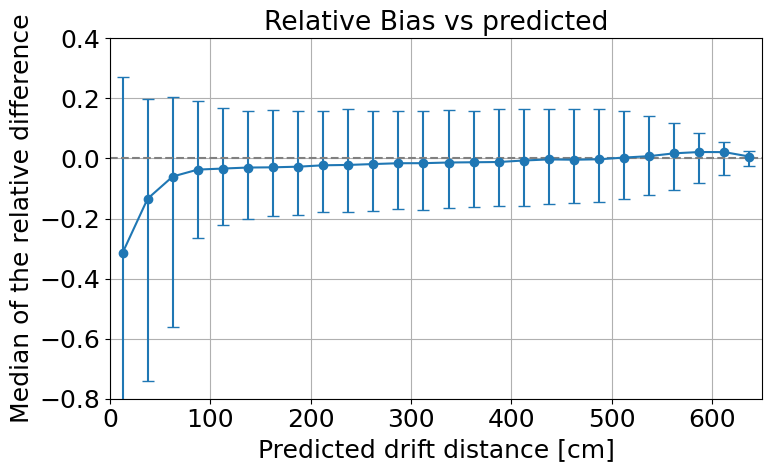

In [12]:
# --------------------------------------------
# 6. Relative bias plot - y range [-0.8, 0.4]
# --------------------------------------------
plt.rcParams.update({"font.size": 16,
                     "axes.labelsize": 18})
fig, ax = plt.subplots(figsize = figsize_summary)


ax.errorbar(
    summary_pred["x_center"],
    summary_pred["rel_bias"],
    yerr = [summary_pred["rel_bias_err_low"], summary_pred["rel_bias_err_high"]],
    fmt = "o-",
    capsize = 4
)

ax.axhline(0, color = "gray", linestyle = "--")
ax.set_xlabel("Predicted drift distance [cm]")
ax.set_ylabel(f"Median of the relative difference")
ax.set_title("Relative Bias vs predicted")
ax.set_xlim([0, 650])
ax.set_ylim([-0.8, 0.4])
ax.grid()
# ax.set_yscale('log')
plt.tight_layout()
plt.show()

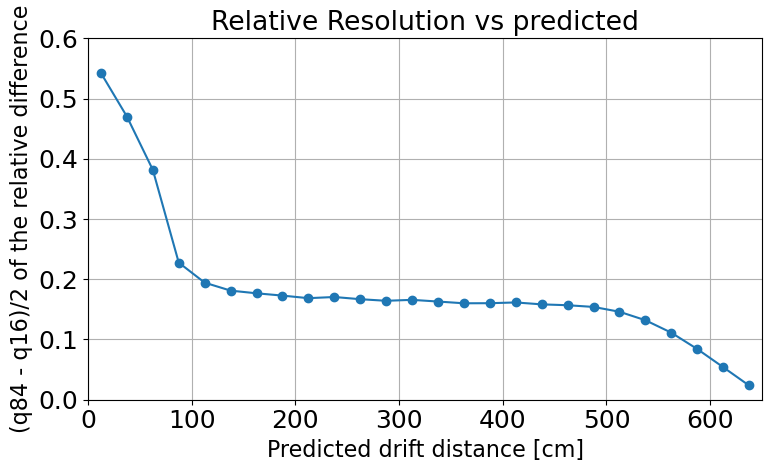

In [13]:
# --------------------------------------------------
# 7. Relative resolution plot - y range [0, 1]
# --------------------------------------------------
plt.rcParams.update({"font.size": 16,
                     "axes.labelsize": 16})
fig, ax = plt.subplots(figsize = figsize_summary)

ax.plot(summary_pred["x_center"], summary_pred["rel_resolution"], "o-")
ax.set_xlabel("Predicted drift distance [cm]")
ax.set_ylabel("(q84 - q16)/2 of the relative difference")
ax.set_title("Relative Resolution vs predicted")
ax.set_xlim([0, 650])
ax.set_ylim([0, 0.6])
ax.grid()
# ax.set_yscale('log')
plt.tight_layout()
plt.show()

## Performance plots w.r.t. true drift distance

In [14]:
work_df, summary = plot_drift_performance(
    df,
    ref_col = "drift_avg",
    compare_col = "pred_drift",
    bin_width = 25
)

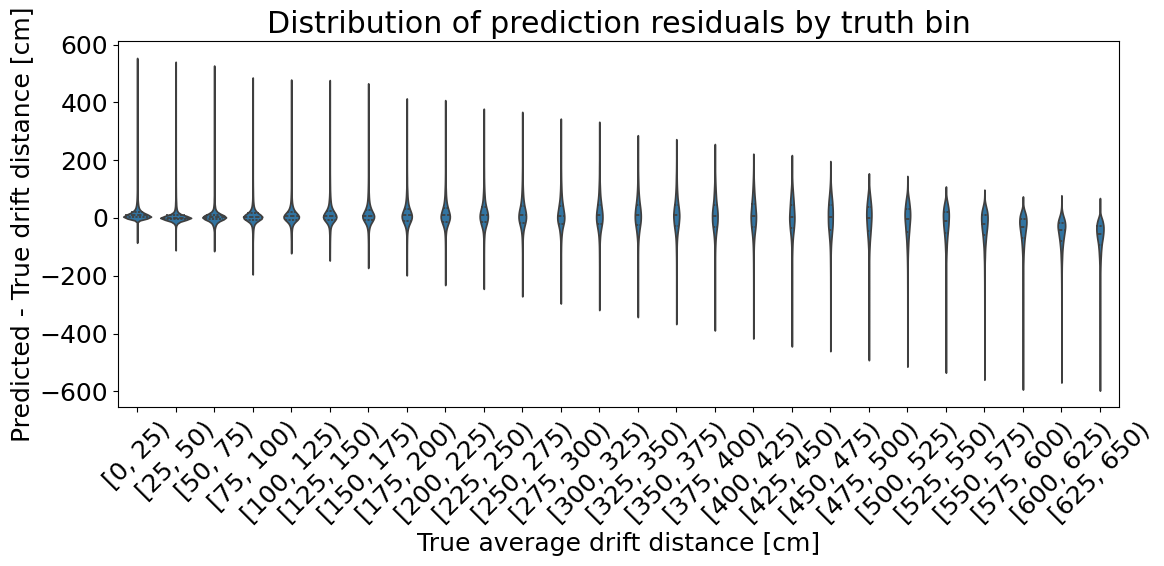

In [15]:
# --------------------
# 1. Violin plot
# --------------------
plt.rcParams.update({"font.size": 18,
                     "axes.labelsize": 18,
                     "xtick.labelsize": 18,
                     "ytick.labelsize": 18,})
fig, ax = plt.subplots(figsize = figsize_violin)

sns.violinplot(
    data = work_df,
    x = "drift_bin_label",
    y = "diff",
    inner = "quartile",
    cut = 0,
    ax = ax
)
ax.set_xlabel(f"True average drift distance [cm]")
ax.set_ylabel(f"Predicted - True drift distance [cm]")
ax.set_title("Distribution of prediction residuals by truth bin")
ax.tick_params(axis = "x", labelrotation = 45)
plt.tight_layout()
plt.show()

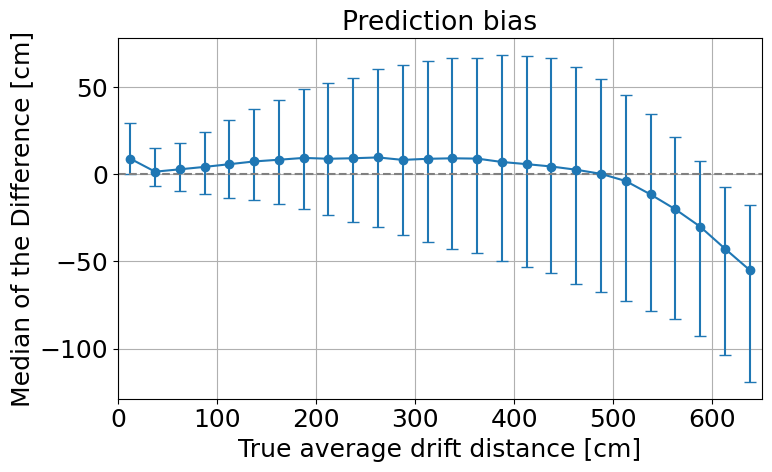

In [16]:
# --------------------
# 2. Bias plot
# --------------------
plt.rcParams.update({"font.size": 16})
fig, ax = plt.subplots(figsize = figsize_summary)

ax.errorbar(
    summary["x_center"],
    summary["bias"],
    yerr = [summary["bias_err_low"], summary["bias_err_high"]],
    fmt = "o-",
    capsize = 4
)

ax.axhline(0, color = "gray", linestyle = "--")
ax.set_xlabel("True average drift distance [cm]")
ax.set_ylabel("Median of the Difference [cm]")
ax.set_title("Prediction bias")
ax.set_xlim([0, 650])
ax.grid()
    
plt.tight_layout()
plt.show()

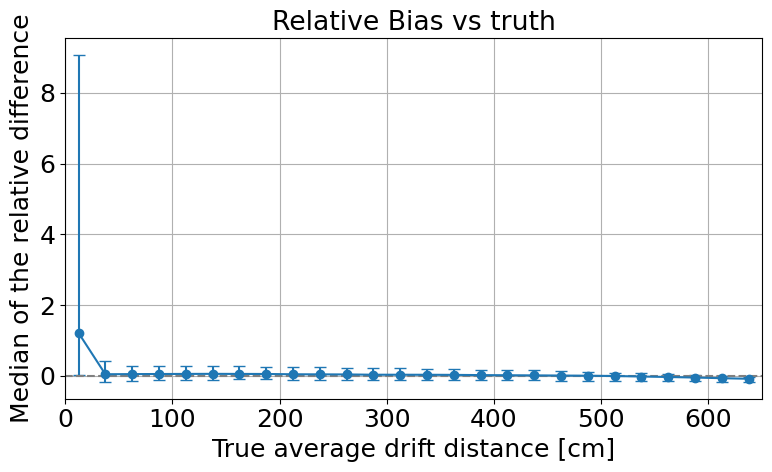

In [17]:
# --------------------
# 4. Relative bias plot
# --------------------
plt.rcParams.update({"font.size": 16})
fig, ax = plt.subplots(figsize = figsize_summary)

ax.errorbar(
    summary["x_center"],
    summary["rel_bias"],
    yerr = [summary["rel_bias_err_low"], summary["rel_bias_err_high"]],
    fmt = "o-",
    capsize = 4
)

ax.axhline(0, color = "gray", linestyle = "--")
ax.set_xlabel("True average drift distance [cm]")
ax.set_ylabel(f"Median of the relative difference")
ax.set_title("Relative Bias vs truth")
ax.set_xlim([0, 650])
ax.grid()
# ax.set_yscale('log')
plt.tight_layout()
plt.show()

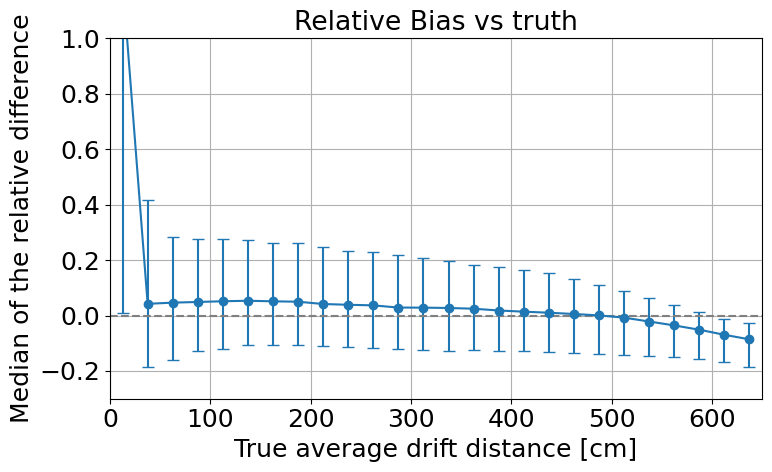

In [18]:
# --------------------------------------------
# 6. Relative bias plot - y range [-0.3, 1]
# --------------------------------------------
plt.rcParams.update({"font.size": 16})
fig, ax = plt.subplots(figsize = figsize_summary)

ax.errorbar(
    summary["x_center"],
    summary["rel_bias"],
    yerr = [summary["rel_bias_err_low"], summary["rel_bias_err_high"]],
    fmt = "o-",
    capsize = 4
)

ax.axhline(0, color = "gray", linestyle = "--")
ax.set_xlabel("True average drift distance [cm]")
ax.set_ylabel(f"Median of the relative difference")
ax.set_title("Relative Bias vs truth")
ax.set_xlim([0, 650])
ax.set_ylim([-0.3, 1])
ax.grid()
# ax.set_yscale('log')
plt.tight_layout()
plt.show()

## Comparison of Tile+Pixel results and Pixel-only results

Do we need the tile readout for the drift distance measurements?  Compare the results from `driftDistanceNN0.1.1_noTile.ipynb`.

W.r.t. true drift distance

In [19]:
infile_pixel = '/Users/yuntse/data/lartpc_rd/gampix/nn/radiologicals/gampixpy_fullgeoanatruth-vd-reduced_g4_00_2Mhz_segmentlabel_lowtrig_5mmpitch_good_r3sd_nn0.1.1_noTile.csv'

In [20]:
df_pixel = pd.read_csv(infile_pixel, header = 0)
df_pixel

,tile_id,event id,start t,tile x,tile y,charge,fit_amp,fit_mu,fit_sigma,fit_rmse,...,ratio_fit,ratio_fit_3sd,E,z_avg,drift_avg,dQdn,ratio_3sd_pixel,dQdn_pixel,pred_drift,isTraining
0,0,0,5806.4365,-1065.0,-575.0,965.778880,173.146760,1.800038,0.939798,50.072464,...,1.081924,0.000000,0.103476,-308.29733,633.297360,482.889440,0.195682,394.755428,371.580847,True
1,2,0,-3550.5635,-1055.0,-575.0,234.433332,43.891174,0.731231,1.514144,58.922040,...,0.983764,0.000000,0.034409,323.14770,1.852295,234.433332,0.459104,486.596345,63.494018,True
2,3,0,-3111.0635,-1055.0,-575.0,1132.180275,1049.915800,1.932631,0.268530,58.317420,...,1.021464,0.822217,0.109424,306.18195,18.818054,566.090137,0.684148,834.046382,44.931382,True
3,4,0,-3154.5635,-1055.0,-565.0,671.969728,673.100800,1.531063,0.240818,37.237630,...,1.114470,0.802374,0.086997,229.34247,95.657530,335.984864,0.850087,556.125693,28.466190,True
4,6,0,3327.9365,-1055.0,-495.0,585.712231,358.198330,1.527334,0.361652,73.776800,...,0.995704,0.878903,0.067363,313.68454,11.315460,585.712231,0.805200,929.333077,20.427575,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
705207,888942,999,-3108.3162,-735.0,-485.0,1205.931701,767.312600,1.814874,0.362555,42.048855,...,1.072088,0.932395,0.112241,301.07280,23.927185,602.965850,0.829061,878.529394,36.573201,True
705208,888943,999,-3057.3162,-735.0,-485.0,4061.857259,2146.497600,1.945175,0.366560,46.033340,...,1.018388,1.018214,0.243623,292.87340,32.126587,2030.928630,0.940115,2100.569498,42.019097,True
705209,888944,999,2226.1838,-735.0,-365.0,1370.368824,532.412540,1.576690,0.344328,70.419945,...,0.824121,0.812401,0.086229,318.06238,6.937622,1370.368824,0.802231,863.021308,12.001645,False
705210,888945,999,2381.1838,-735.0,-355.0,34824.065399,4619.398400,5.120800,1.504715,91.878580,...,1.002991,0.857276,1.790287,-314.51718,639.517200,2487.433243,0.857257,2464.853243,650.419899,False


In [21]:
work_df_pixel, summary_pixel = plot_drift_performance(
    df_pixel,
    ref_col = "drift_avg",
    compare_col = "pred_drift",
    bin_width = 25
)

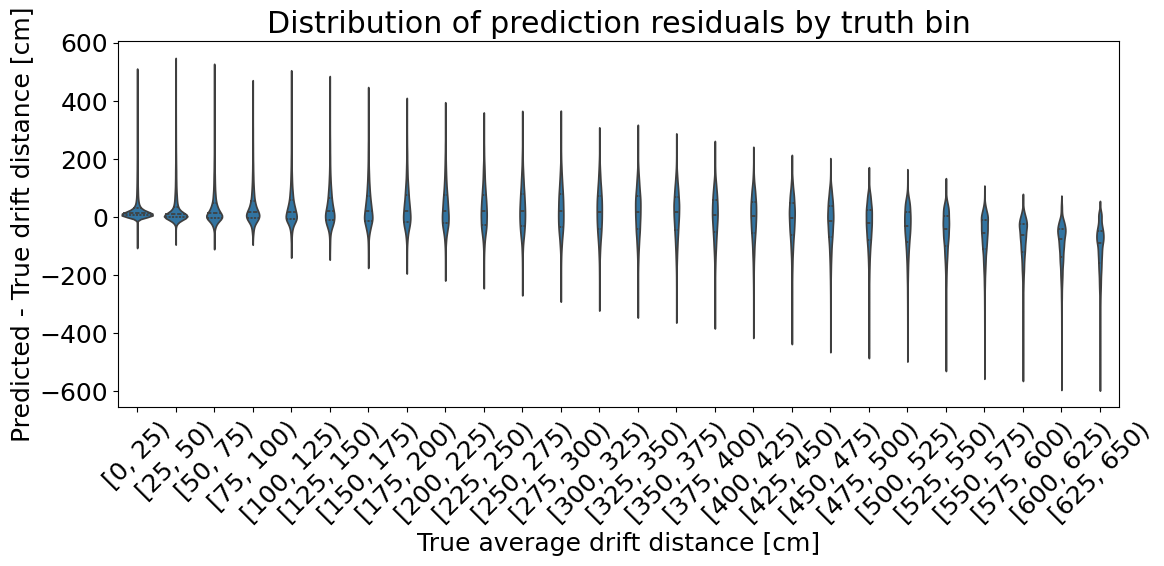

In [22]:
# --------------------
# 1. Violin plot
# --------------------
plt.rcParams.update({"font.size": 18,
                     "axes.labelsize": 18,
                     "xtick.labelsize": 18,
                     "ytick.labelsize": 18,})
fig, ax = plt.subplots(figsize = figsize_violin)

sns.violinplot(
    data = work_df_pixel,
    x = "drift_bin_label",
    y = "diff",
    inner = "quartile",
    cut = 0,
    ax = ax
)
ax.set_xlabel(f"True average drift distance [cm]")
ax.set_ylabel(f"Predicted - True drift distance [cm]")
ax.set_title("Distribution of prediction residuals by truth bin")
ax.tick_params(axis = "x", labelrotation = 45)
plt.tight_layout()
plt.show()

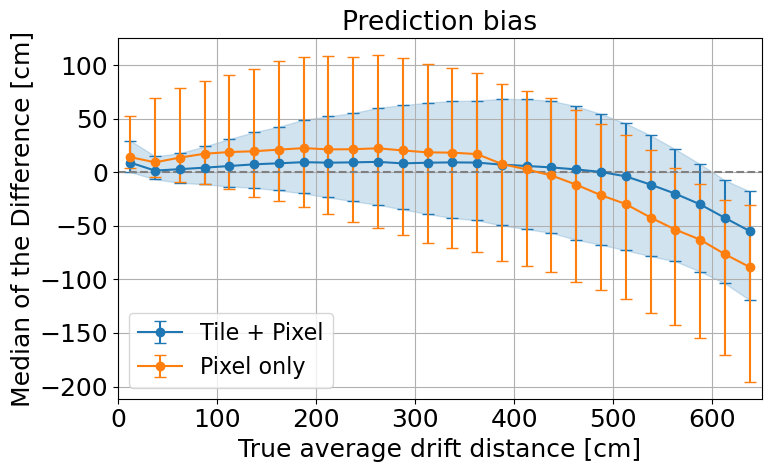

In [23]:
# --------------------
# 2. Bias plot
# --------------------
plt.rcParams.update({"font.size": 16})
fig, ax = plt.subplots(figsize = figsize_summary)

ax.errorbar(
    summary["x_center"],
    summary["bias"],
    yerr = [summary["bias_err_low"], summary["bias_err_high"]],
    fmt = "o-",
    capsize = 4,
    label = 'Tile + Pixel'
)
ax.fill_between(summary["x_center"], summary["bias"] - summary["bias_err_low"], summary["bias"] + summary["bias_err_high"], color = 'tab:blue', alpha = 0.2)

ax.errorbar(
    summary_pixel["x_center"],
    summary_pixel["bias"],
    yerr = [summary_pixel["bias_err_low"], summary_pixel["bias_err_high"]],
    fmt = "o-",
    capsize = 4,
    label = 'Pixel only'
)


ax.axhline(0, color = "gray", linestyle = "--")
ax.set_xlabel("True average drift distance [cm]")
ax.set_ylabel("Median of the Difference [cm]")
ax.set_title("Prediction bias")
ax.set_xlim([0, 650])
ax.grid()
ax.legend()
    
plt.tight_layout()
plt.show()

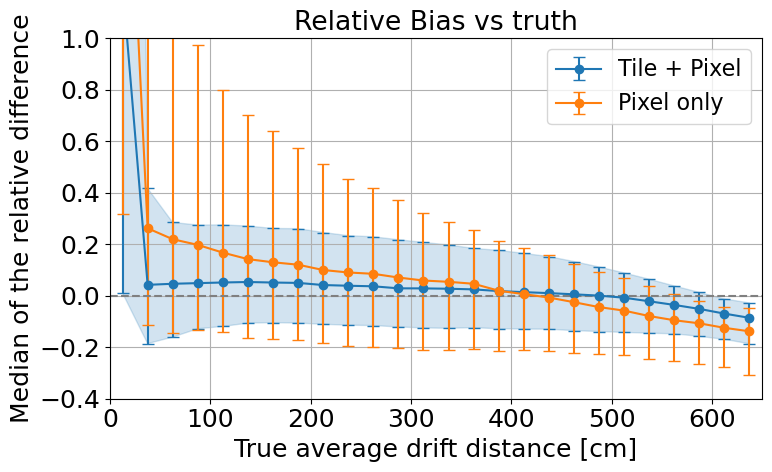

In [24]:
# --------------------
# 4. Relative bias plot
# --------------------
plt.rcParams.update({"font.size": 16})
fig, ax = plt.subplots(figsize = figsize_summary)

ax.errorbar(
    summary["x_center"],
    summary["rel_bias"],
    yerr = [summary["rel_bias_err_low"], summary["rel_bias_err_high"]],
    fmt = "o-",
    capsize = 4,
    label = 'Tile + Pixel'
)
ax.fill_between(summary["x_center"], summary["rel_bias"] - summary["rel_bias_err_low"], summary["rel_bias"] + summary["rel_bias_err_high"], color = 'tab:blue', alpha = 0.2)

ax.errorbar(
    summary_pixel["x_center"],
    summary_pixel["rel_bias"],
    yerr = [summary_pixel["rel_bias_err_low"], summary_pixel["rel_bias_err_high"]],
    fmt = "o-",
    capsize = 4,
    label = 'Pixel only'
)

ax.axhline(0, color = "gray", linestyle = "--")
ax.set_xlabel("True average drift distance [cm]")
ax.set_ylabel(f"Median of the relative difference")
ax.set_title("Relative Bias vs truth")
ax.set_xlim([0, 650])
ax.set_ylim([-0.4, 1])
ax.grid()
# ax.set_yscale('log')
ax.legend()

plt.tight_layout()
plt.show()